In [1]:
import ast
import json
import torch
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
from huggingface_hub import login

# from processing import TokenizerProcessor

/Users/fixed/Desktop/saar/thesis/word-order-thesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/fixed/Desktop/saar/thesis/word-order-thesis/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Loading Dataframes

In [12]:
dataframes = {
    "gptneo": pd.read_csv("../output/ger-fre/gptneo/noun-adj_b1rus_b2ger_s1ned_s2fre.csv"),
    "mgpt": pd.read_csv("../output/ger-fre/mgpt/noun-adj_b1rus_b2ger_s1ned_s2fre.csv"),
    "llama": pd.read_csv("../output/ger-fre/llama/noun-adj_b1rus_b2ger_s1ned_s2fre.csv"),
}
token_types = [
    'noun-rus', 'noun-ger', 'noun-ned', 'noun-fre', 'noun-eng', 'adj-rus', 'adj-ger', 'adj-ned', 'adj-fre', 'adj-eng'
    ]
for df in dataframes.values():
    for t in token_types:
        df[t] = df.probabilities.apply(lambda x: json.loads(x)[t] if t in json.loads(x) else None)

# Plotting

## Per Layer

In [13]:
sorted(dataframes['mgpt'][
    dataframes['mgpt'].layer_combination.apply(lambda x: len(ast.literal_eval(x)) == 1)
    ].layer_combination.unique(), key=lambda x: x[0])

['[0]',
 '[1]',
 '[2]',
 '[3]',
 '[4]',
 '[5]',
 '[6]',
 '[7]',
 '[8]',
 '[9]',
 '[10]',
 '[11]',
 '[12]',
 '[13]',
 '[14]',
 '[15]',
 '[16]',
 '[17]',
 '[18]',
 '[19]',
 '[20]',
 '[21]',
 '[22]',
 '[23]']

/var/folders/3r/9jqdq_gj6v15n9p38lj3pd680000gn/T/ipykernel_58242/1041284840.py:23: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  layer_means = df.groupby('layer_combination').mean()
/var/folders/3r/9jqdq_gj6v15n9p38lj3pd680000gn/T/ipykernel_58242/1041284840.py:23: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  layer_means = df.groupby('layer_combination').mean()
/var/folders/3r/9jqdq_gj6v15n9p38lj3pd680000gn/T/ipykernel_58242/1041284840.py:23: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeri

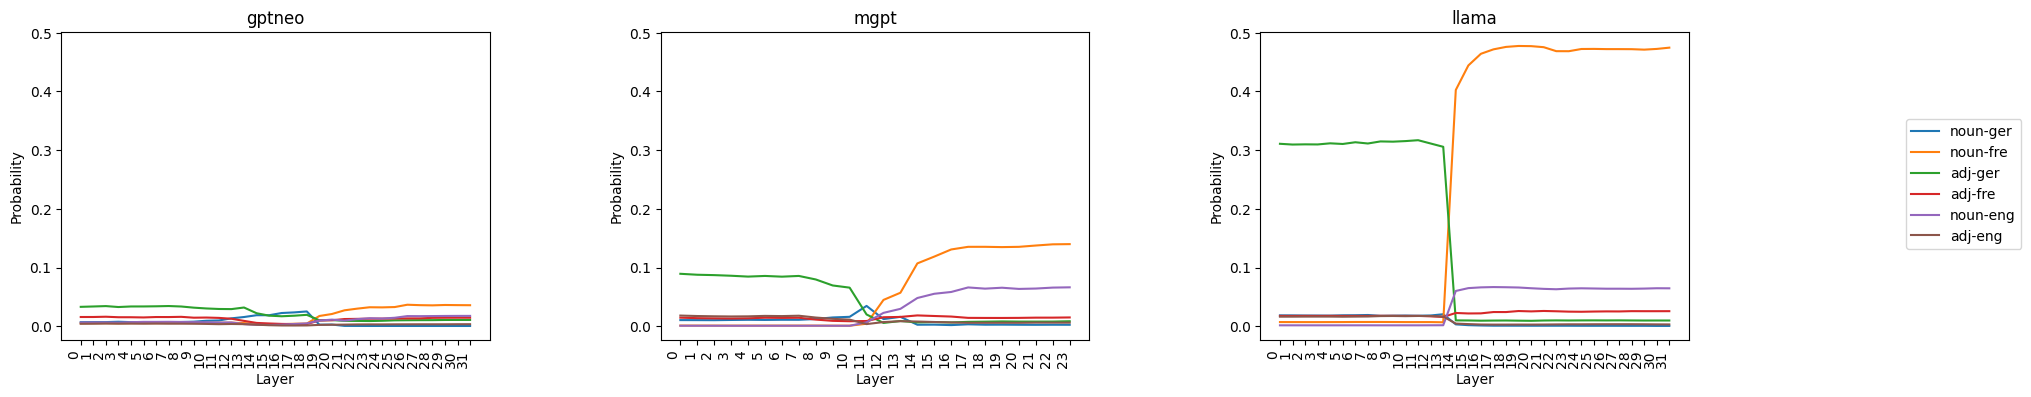

In [14]:
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(7 * len(dataframes), 4))
gs = gridspec.GridSpec(1, len(dataframes), figure=fig)  # nrows=1, ncols=len(dataframes)
axes = []
shared_ax = None
for i, (model, df) in enumerate(dataframes.items()):
    if i == 0:
        ax = fig.add_subplot(gs[0, i])
        shared_ax = ax
    else:
        ax = fig.add_subplot(gs[0, i], sharey=shared_ax)
    axes.append(ax)
    ax.set_title(f"{model}")
    ax.set_ylabel("Probability")
    ax.set_xlabel("Layer")
    layers = sorted(
        df[
            df.layer_combination.apply(lambda x: len(ast.literal_eval(x)) == 1)
        ].layer_combination.unique(),
        key=lambda x: x[0])
    ax.set_xticks(range(len(layers)))
    ax.set_xticklabels([str(l).strip('[]') for l in layers], rotation=90, ha='right')
    layer_means = df.groupby('layer_combination').mean()
    for t in ['noun-ger', 'noun-fre', 'adj-ger', 'adj-fre', 'noun-eng', 'adj-eng']:
        y = [layer_means[t][l] for l in layers]
        x = range(len(y))
        ax.plot(x, y, label=t)
# Set y-limits to be the same for all axes
ymins, ymaxs = zip(*(ax.get_ylim() for ax in axes))
ymin = min(ymins)
ymax = max(ymaxs)
for ax in axes:
    ax.set_ylim(ymin, ymax)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5))
plt.subplots_adjust(wspace=0.4)
plt.show()

In [88]:
# filter those rows where layer_combination is a single item list
ger_fre_df_single_layers = ger_fre_df[ger_fre_df.layer_combination.apply(lambda x: len(ast.literal_eval(x)) == 1)]

In [89]:
ger_fre_df_single_layers.groupby('layer_combination').mean()['noun-rus']

/var/folders/3r/9jqdq_gj6v15n9p38lj3pd680000gn/T/ipykernel_96120/1255017903.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ger_fre_df_single_layers.groupby('layer_combination').mean()['noun-rus']


layer_combination
[0]     0.000063
[10]    0.000029
[11]    0.000032
[12]    0.000026
[13]    0.000056
[14]    0.000185
[15]    0.000503
[16]    0.000982
[17]    0.002107
[18]    0.001243
[19]    0.002216
[1]     0.000057
[20]    0.001891
[21]    0.000294
[22]    0.000231
[23]    0.000095
[24]    0.000035
[25]    0.000030
[26]    0.000028
[27]    0.000027
[28]    0.000026
[29]    0.000021
[2]     0.000052
[30]    0.000020
[31]    0.000018
[3]     0.000048
[4]     0.000045
[5]     0.000034
[6]     0.000034
[7]     0.000032
[8]     0.000034
[9]     0.000027
Name: noun-rus, dtype: float64

In [90]:
layers = [str([l]) for l in range(24)]

In [91]:
import matplotlib.pyplot as plt

In [92]:
layer_means = ger_fre_df_single_layers.groupby('layer_combination').mean()

/var/folders/3r/9jqdq_gj6v15n9p38lj3pd680000gn/T/ipykernel_96120/2839601492.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  layer_means = ger_fre_df_single_layers.groupby('layer_combination').mean()


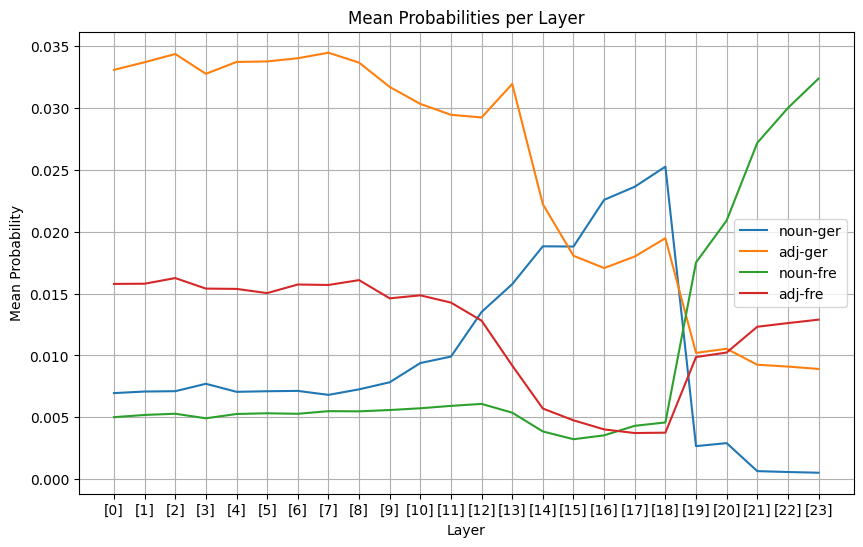

In [93]:
plt.figure(figsize=(10, 6))
for t in ['noun-ger', 'adj-ger', 'noun-fre', 'adj-fre']:
    plt.plot(layers, [layer_means[t][l] for l in layers], label=t)
# plt.plot(layers, [layer_means['C_ls_t'] for l in layers], label='C_ls_t')
# plt.plot(layers, [layer_means['C_lt_s'] for l in layers], label='C_lt_s')
# plt.plot(layers, [layer_means['C_lt_t'] for l in layers], label='C_lt_t')
plt.xlabel('Layer')
plt.ylabel('Mean Probability')
plt.title('Mean Probabilities per Layer')
plt.legend()
plt.grid(True)
plt.show()